In [1]:
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt

In [2]:
#Define output directory for the data
datadir = '/home/jovyan/SAMBBA_data/'

In [5]:
with open(datadir+'/man-sp2_faam_20120929_r0_b746.na', "rb") as f:
    lines = f.readlines()  # Read the first 100 bytes
print(lines[:39])  # Print the first 5 lines

[b'39 1001\r\n', b'Will Morgan, Michael Flynn\r\n', b'School of Earth, Atmospheric and Environmental Science, The University of Manchester\r\n', b'Single Particle Soot Photometer (SP2)\r\n', b'SAMBBA\r\n', b'1 1\r\n', b'2012 09 29 2014 07 02\r\n', b'0\r\n', b'Time_UTC (seconds from 0000 UTC on start day)\r\n', b'3\r\n', b'1 1 1 \r\n', b'9999999 9999999 9999999 \r\n', b'BC mass concentration (ng m-3)\r\n', b'BC number concentration (cm-3)\r\n', b'Non-BC scattering number concentration (cm-3)\r\n', b'16\r\n', b'PI_CONTACT_INFO: Centre for Atmospheric Science, School of Earth, Atmospheric and Environmental Science, University of Manchester, Simon Building, Oxford Road, Manchester, M13 9PL ; william.morgan@manchester.ac.uk; 44-161-306-6586\r\n', b'PLATFORM: FAAM BAE146\r\n', b'LOCATION: See FAAM NETCDF file on BADC\r\n', b'ASSOCIATED_DATA: See FAAM NETCDF file on BADC\r\n', b'INSTRUMENT_INFO: Droplet Measurement Technologies Single Particle Soot Photometer\r\n', b'DATA_INFO: N/A\r\n', b'UN

In [13]:
metadata_lines = lines[:39]  # Assume first 5 lines are metadata
header_line = metadata_lines[38].strip().split()  # Extract header names
# Decode if header contains byte strings
header_line = [h.decode("utf-8") if isinstance(h, bytes) else h for h in header_line]
# Decode if metadata contains byte strings
metadata_lines = [line.decode("utf-8").strip() if isinstance(line, bytes) else line.strip() for line in metadata_lines]
header_line

['Time_UTC', 'BC_mass', 'BC_number', 'Scatter_number']

In [15]:
data_lines = lines[39:]  # Actual data starts after metadata

In [16]:
# Print extracted metadata and headers
for i, line in enumerate(metadata_lines[:45], 1):  # Exclude header itself
    print(f"Metadata {i}: {line.strip()}")

print(f"Header: {header_line}")

Metadata 1: 39 1001
Metadata 2: Will Morgan, Michael Flynn
Metadata 3: School of Earth, Atmospheric and Environmental Science, The University of Manchester
Metadata 4: Single Particle Soot Photometer (SP2)
Metadata 5: SAMBBA
Metadata 6: 1 1
Metadata 7: 2012 09 29 2014 07 02
Metadata 8: 0
Metadata 9: Time_UTC (seconds from 0000 UTC on start day)
Metadata 10: 3
Metadata 11: 1 1 1
Metadata 12: 9999999 9999999 9999999
Metadata 13: BC mass concentration (ng m-3)
Metadata 14: BC number concentration (cm-3)
Metadata 15: Non-BC scattering number concentration (cm-3)
Metadata 16: 16
Metadata 17: PI_CONTACT_INFO: Centre for Atmospheric Science, School of Earth, Atmospheric and Environmental Science, University of Manchester, Simon Building, Oxford Road, Manchester, M13 9PL ; william.morgan@manchester.ac.uk; 44-161-306-6586
Metadata 18: PLATFORM: FAAM BAE146
Metadata 19: LOCATION: See FAAM NETCDF file on BADC
Metadata 20: ASSOCIATED_DATA: See FAAM NETCDF file on BADC
Metadata 21: INSTRUMENT_INFO:

In [20]:
# Parse data into a NumPy array
data_array = np.array([line.strip().split() for line in data_lines], dtype=float)

# Define dimensions (assuming first column is time and others are variables)
dims = ("time", "variable")  # Modify as needed
time_coords = np.arange(data_array.shape[0])  # Placeholder for time index

# Convert to xarray Dataset with headers as variable names
ds = xr.Dataset(
    {name: ("time", data_array[:, i]) for i, name in enumerate(header_line)},
    coords={"time": time_coords},
    attrs={"Metadata": "\n".join(metadata_lines[:38])}  # Store metadata as an attribute
)

ds

<xarray.Dataset> Size: 921kB
Dimensions:         (time: 23027)
Coordinates:
  * time            (time) int64 184kB 0 1 2 3 4 ... 23023 23024 23025 23026
Data variables:
    Time_UTC        (time) float64 184kB 3.697e+04 3.697e+04 ... 6e+04 6e+04
    BC_mass         (time) float64 184kB 1e+07 1e+07 1e+07 ... 1.305e+03 183.3
    BC_number       (time) float64 184kB 1e+07 1e+07 1e+07 ... 3.107e+03 498.2
    Scatter_number  (time) float64 184kB 1e+07 1e+07 1e+07 ... 344.8 375.5 325.6
Attributes:
    Metadata:  39 1001\nWill Morgan, Michael Flynn\nSchool of Earth, Atmosphe...

In [22]:
def convert_time_to_datetime(dsf, start_date_str):
    """
    Convert the 'Time_start_UTC' variable (seconds from 00:00 UTC) into datetime format.
    
    Parameters:
    - ds (xarray.Dataset): The dataset containing 'Time_start_UTC'
    - start_date_str (str): Start date in "YYYY MM DD" format
    
    Returns:
    - xarray.Dataset: Dataset with a new 'datetime' coordinate
    """
    # Convert start_date string to datetime object
    start_date = datetime.strptime(start_date_str, "%Y %m %d")
    
    # Extract 'Time_start_UTC' variable (seconds from 00:00 UTC)
    time_seconds = dsf["Time_UTC"].values
    
    # Convert seconds to actual datetime
    datetime_values = np.array([start_date + timedelta(seconds=int(sec)) for sec in time_seconds])

    # Assign datetime as a coordinate in the dataset
    dsf = dsf.assign_coords(datetime=("time", datetime_values))

    return dsf

# Example usage
start_date = "2012 09 29"  # Example start date

# Convert time
ds0 = convert_time_to_datetime(ds, start_date)

# Print updated dataset with datetime coordinate
ds0


<xarray.Dataset> Size: 1MB
Dimensions:         (time: 23027)
Coordinates:
  * time            (time) int64 184kB 0 1 2 3 4 ... 23023 23024 23025 23026
    datetime        (time) datetime64[ns] 184kB 2012-09-29T10:16:13 ... 2012-...
Data variables:
    Time_UTC        (time) float64 184kB 3.697e+04 3.697e+04 ... 6e+04 6e+04
    BC_mass         (time) float64 184kB 1e+07 1e+07 1e+07 ... 1.305e+03 183.3
    BC_number       (time) float64 184kB 1e+07 1e+07 1e+07 ... 3.107e+03 498.2
    Scatter_number  (time) float64 184kB 1e+07 1e+07 1e+07 ... 344.8 375.5 325.6
Attributes:
    Metadata:  39 1001\nWill Morgan, Michael Flynn\nSchool of Earth, Atmosphe...

In [23]:
# Filter out invalid BC mass values (9999999)
valid_BC_mass_mask = ds0["BC_mass"] != 9999999
filtered_ds_BC_mass = ds0.where(valid_BC_mass_mask, drop=True)

# Filter out invalid BC number values (9999999)
valid_BC_number_mask = ds0["BC_mass"] != 9999999
filtered_ds_BC_number = ds0.where(valid_BC_number_mask, drop=True)


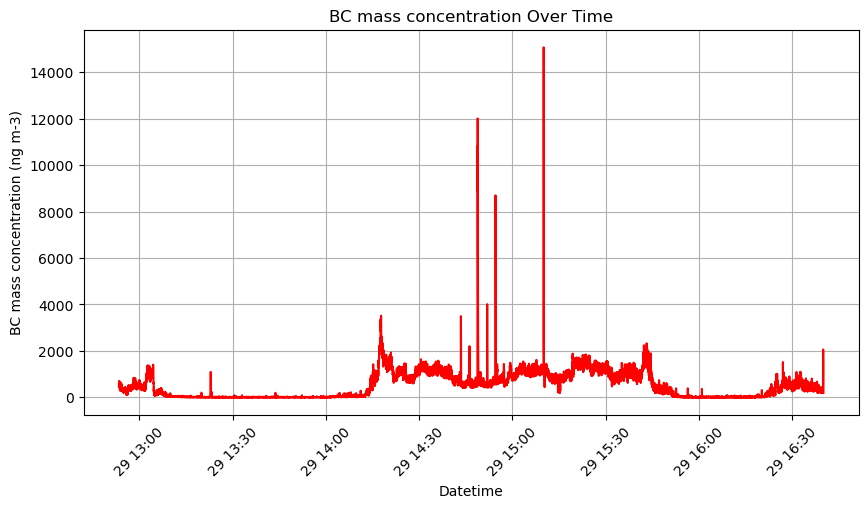

In [26]:
# Plot SO4 vs. datetime
plt.figure(figsize=(10, 5))
plt.plot(filtered_ds_BC_mass.datetime, filtered_ds_BC_mass["BC_mass"], color="r")

# Formatting
plt.xlabel("Datetime")
plt.ylabel("BC mass concentration (ng m-3)")
plt.title("BC mass concentration Over Time")
plt.xticks(rotation=45)
plt.grid()

# Show plot
plt.show()